____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [4]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [5]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

_______
# Count 

In [6]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0, 1])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[2, 3])


nofilter__swot250naive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [7]:
DS.dropna('row_number')

<xarray.Dataset> Size: 366MB
Dimensions:        (id_comb: 4, row_number: 284359)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 9MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 9MB 4.812 4.812 ... 2.415 2.414
    latitude       (id_comb, row_number) float64 9MB 42.22 42.22 ... 39.79 39.79
    pass_number    (id_comb, row_number) float64 9MB 3.0 3.0 3.0 ... 16.0 16.0
    time_to_swot   (id_comb, row_number) timedelta64[ns] 9MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) float64 9MB 478.0 478.0 ... 577.0 577.0
    drifter_id     (id_comb, row_number) object 9MB '300534060315840' ... '30...
    drifter_type   (id_comb, row_number) object 9MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth          (id_comb, row_number) float64 9MB 15.0 15.0 ... 15.0 15.0
    phi            (id_comb, row_number) float64 9MB 1.809 1.809 ... 2.917 2.917
  * row_number     (row_number) int64 2MB 0 1 2 3 ... 404302 404303 404304
  * id_comb        (id_comb) <U39 624B 'nofilter__swot250naive_etaf__rio_0era...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 9MB -1.484e-05 ... 1.222e-05
    acce           (id_comb, row_number) float64 9MB 6.386e-06 ... -1.995e-06
    exce_acc       (id_comb, row_number) float64 9MB -2.123e-05 ... 1.422e-05
    core           (id_comb, row_number) float64 9MB -1.001e-05 ... -1.024e-05
    exce_cor       (id_comb, row_number) float64 9MB -4.826e-06 ... 2.247e-05
    ggde           (id_comb, row_number) float64 9MB 1.448e-05 ... 2.331e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 9MB -7.476e-11 ... -1.039e-10
    prodn_acc_ggd  (id_comb, row_number) float64 9MB -1.83e-10 ... -1.523e-10
    prodn_acc_wd   (id_comb, row_number) float64 9MB 9.674e-11 ... 1.205e-11
    prodn_cor_ggd  (id_comb, row_number) float64 9MB 9.333e-11 ... 2.395e-10
    prodn_cor_wd   (id_comb, row_number) float64 9MB -4.933e-11 ... -1.894e-11
    prodn_ggd_wd   (id_comb, row_number) float64 9MB -1.208e-10 ... -2.779e-11

In [8]:
DSD50 =  DS.where(DS.depth==50, drop=True).isel(id_comb=0)
DSD100 =  DS.where(DS.depth==100, drop=True).isel(id_comb=0)
print('Nb coloc SWOT 250m : all, surface, 15m, 50m, 100m')
print(len(DS.isel(id_comb=0).to_dataframe().dropna()),
      len(DSS.to_dataframe().dropna()),
      len(DSD.to_dataframe().dropna()),
      len(DSD50.to_dataframe().dropna()),
      len(DSD100.to_dataframe().dropna()),
     )


Nb coloc SWOT 250m : all, surface, 15m, 50m, 100m
284359 299806 240002 6483 7972


__________________
## Sensitivity to SWOT-250m filtering

149903
10.014195669715553
10.546989273002326
9.645699330774965
9.800788837141425
8.303533262688163
8.775085601321596
7.878705106304506
8.081816649684919


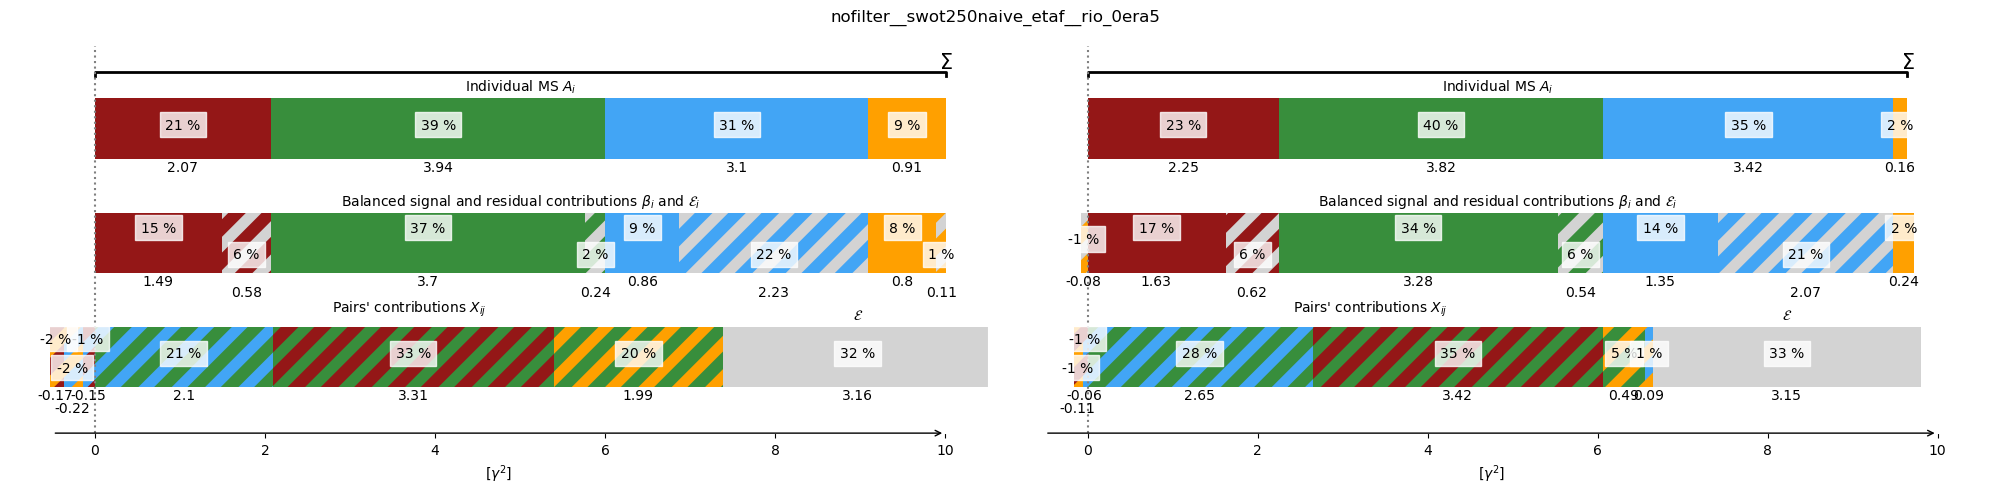

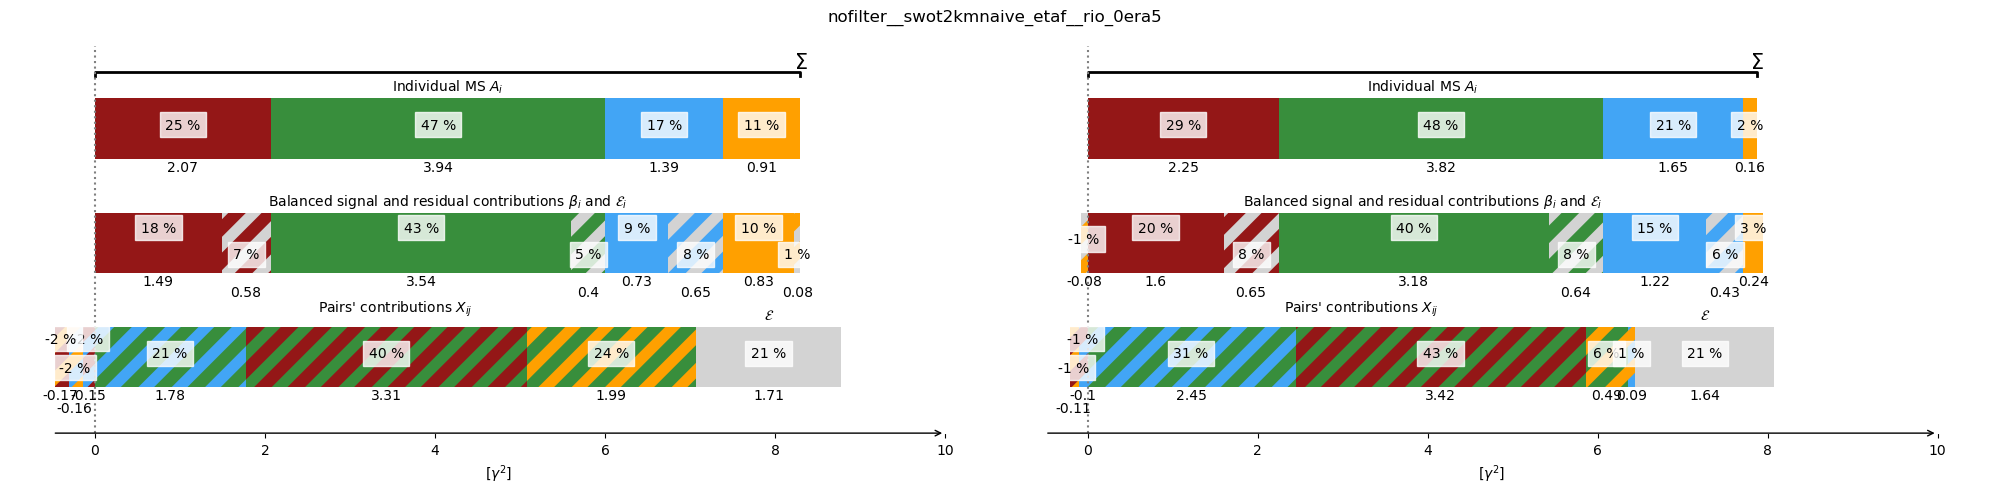

In [10]:
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

120001
6.100007950661932
6.257156415505268
6.981746448764912
7.176517461826619
4.926540308817347
5.110942566545324
5.767237814125751
5.959784225349758


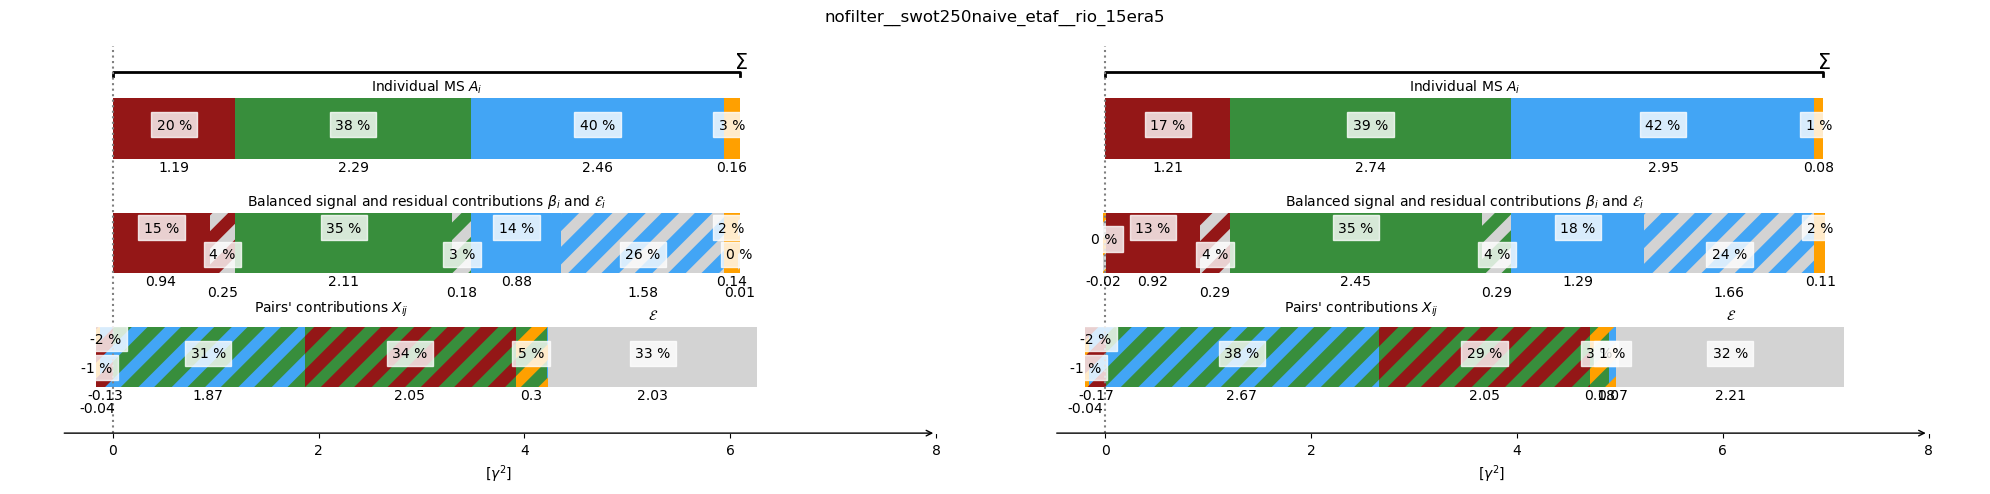

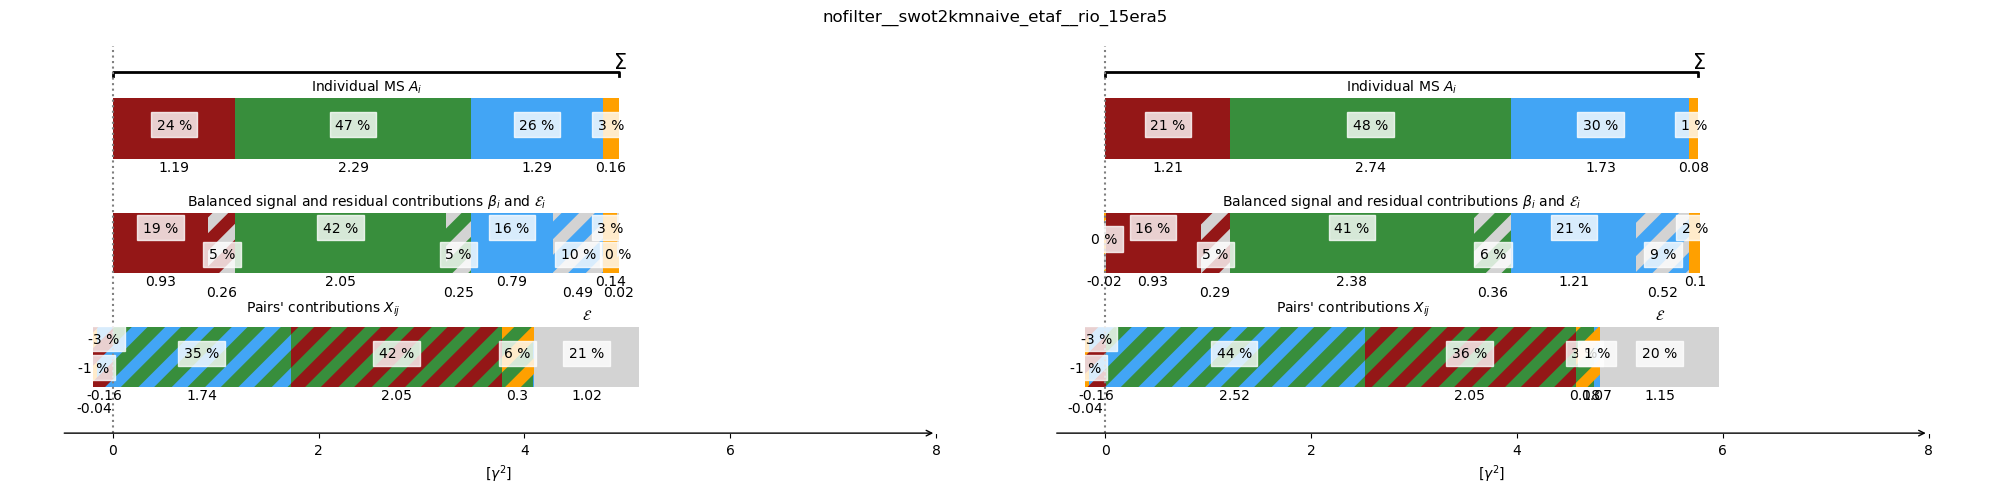

In [11]:
ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()
print(DSD.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

__________________
## Sensitivity to SWOT-250m filtering

nofilter__swot250naive_etaf__rio_0era5
nofilter__swot250gauss1e3_etaf__rio_0era5
nofilter__swot250gauss2e3_etaf__rio_0era5
nofilter__swot250gauss3e3_etaf__rio_0era5
nofilter__swot250gauss4e3_etaf__rio_0era5
nofilter__swot250gauss5e3_etaf__rio_0era5
7.025788504223055
7.2804475799539965
8.769876426580538
8.818816680720133
6.665989303340561
6.938616602620302
8.35134259566471
8.397585127788632
6.190465839722849
6.441871860777303
7.815365566842426
7.855570213198912
5.806342313158906
6.034874520842535
7.289641610662248
7.334497535788665
5.533283466478967
5.746233846834669
6.8624666139457435
6.916457238345978
5.331190174759487
5.5333737896756094
6.531863950101756
6.588571053830221


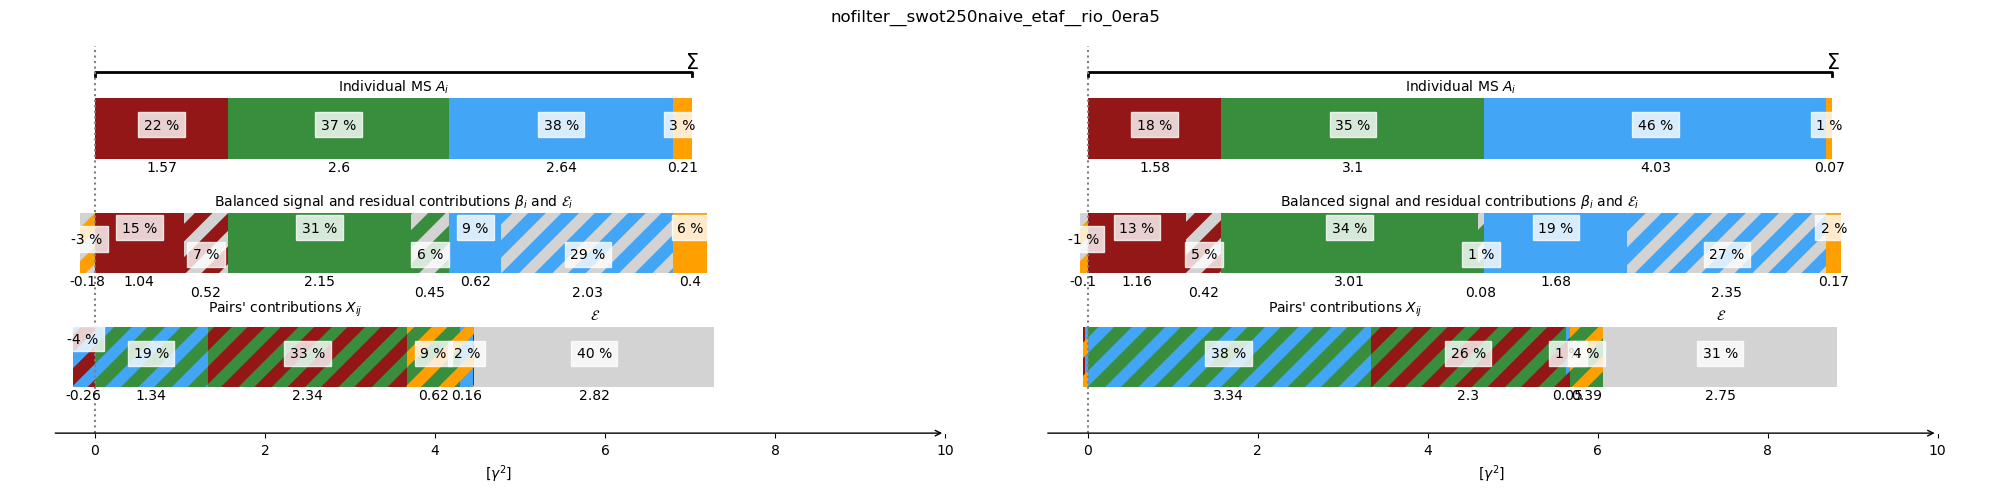

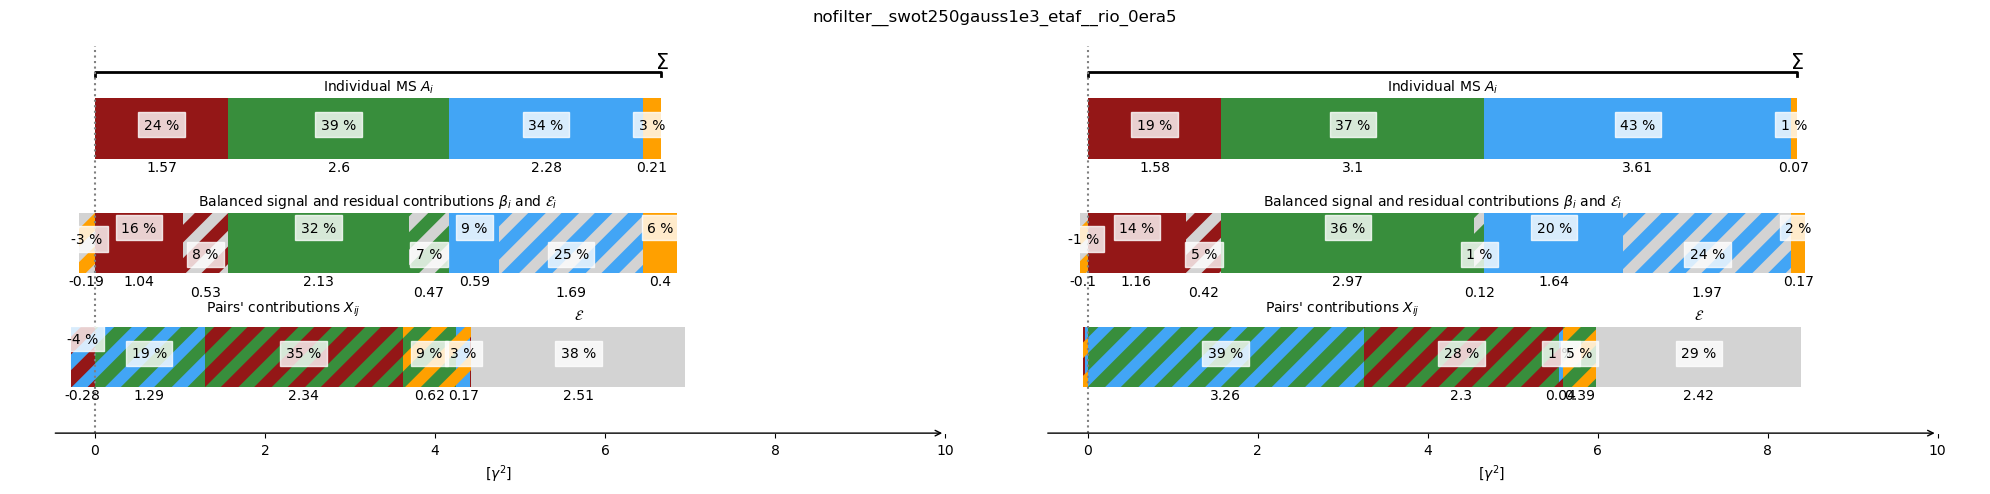

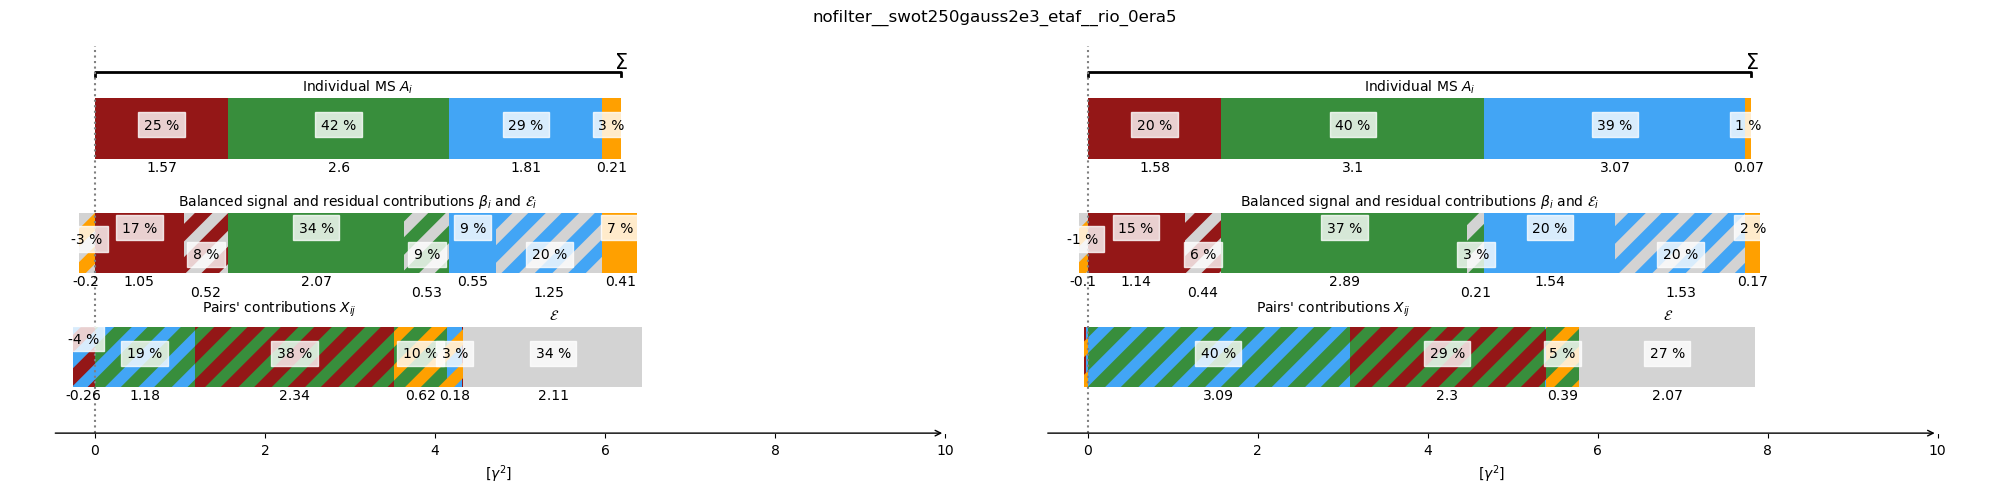

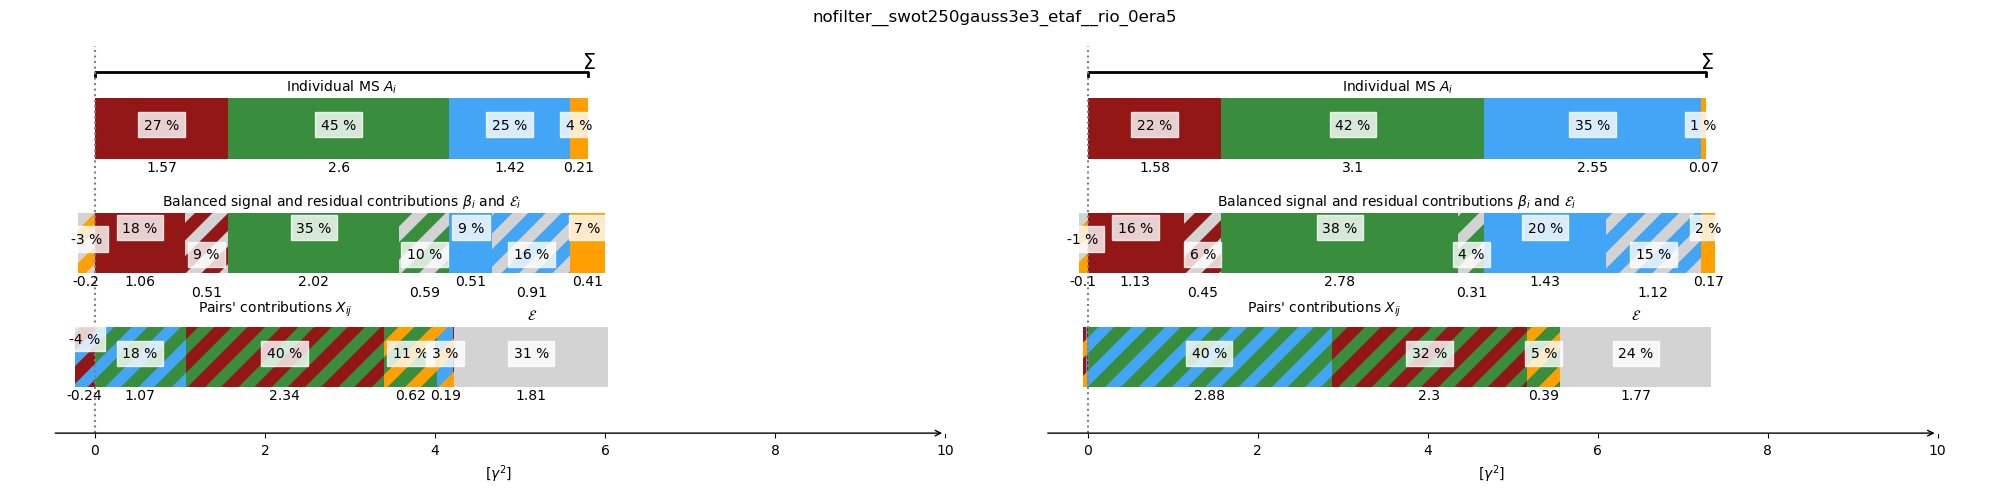

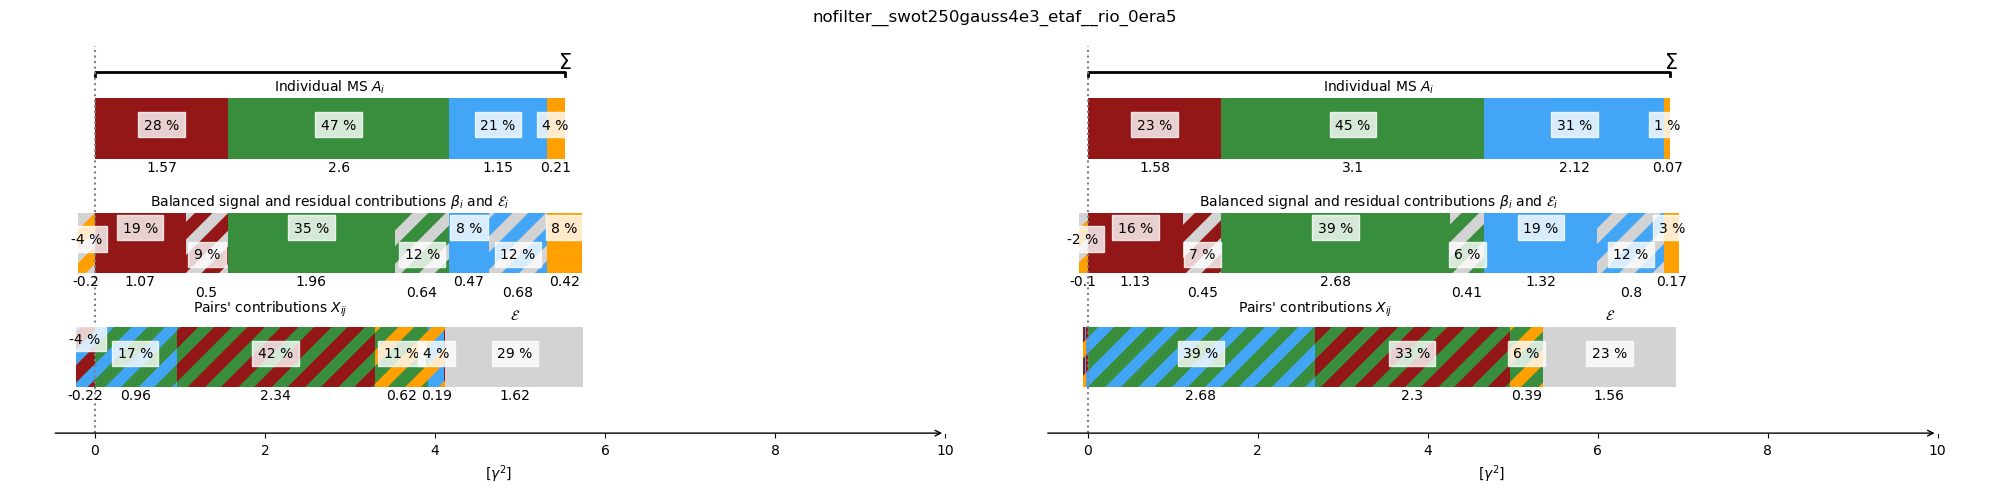

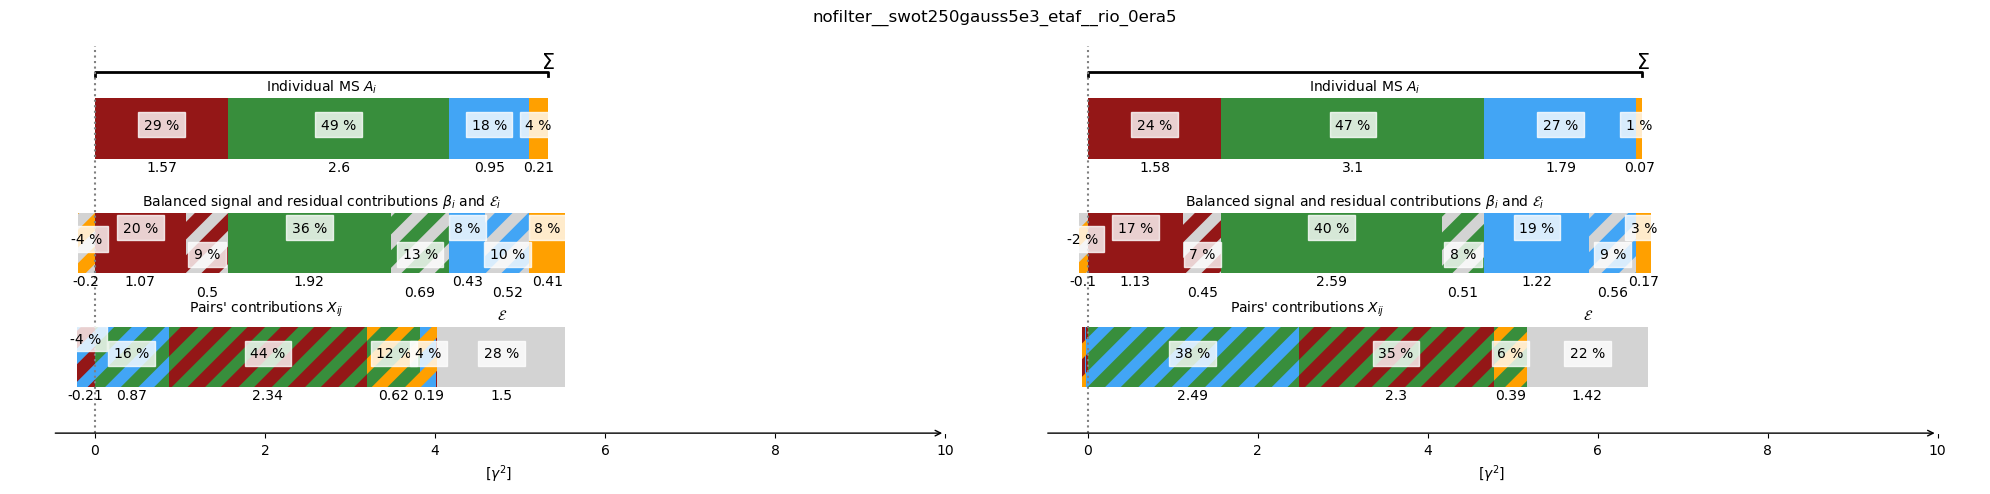

In [9]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')>12).drop_sel(row_number = err_acc).dropna('row_number')
a = 3e-4
DS = DS.where((abs(DS.ggde)<a) & (abs(DS.ggdn)<a), drop=True) #delete ggd outliers
DSS = DS.where(DS.depth==0, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))